# Training Check

This notebook is a self-contained version of the project.

It keeps the same overall workflow as the codebase:
- define the project configuration
- download and load ImageNette
- build the CNN with MC Dropout
- train the model with early stopping
- evaluate, save, and run a small uncertainty check


## 1. Setup and Environment Check

This cell imports the libraries we need, checks TensorFlow, and finds the project root so local paths work whether the notebook starts in the repository root or in the `notebooks/` folder.

In [1]:
%pip install wandb


In [2]:
import json
import os
from dataclasses import asdict, dataclass, field, replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

IS_COLAB = "COLAB_GPU" in os.environ

if IS_COLAB:
    PROJECT_ROOT = Path("/content/DAT255_Bayesian")
else:
    PROJECT_ROOT = Path.cwd().resolve()
    if not (PROJECT_ROOT / "requirements.txt").exists() and (PROJECT_ROOT.parent / "requirements.txt").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU devices: {tf.config.list_physical_devices('GPU')}")


Project root: /content/DAT255_Bayesian
TensorFlow version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import wandb
from wandb.integration.keras import WandbMetricsLogger

WANDB_PROJECT = "dat255-bayesian"
WANDB_ENTITY = None
WANDB_GROUP = "notebook-04-dropout-sweep-v3"
WANDB_API_KEY = "key"
WANDB_BEST_MODEL_ARTIFACT = "notebook-04-best-model"
WANDB_RESULTS_ARTIFACT = "notebook-04-experiment-results"
LOAD_MODEL_FROM_WANDB_ARTIFACTS = True

if WANDB_API_KEY == "key":
    raise ValueError("Replace WANDB_API_KEY with your W&B API key before running this cell.")

wandb.login(key=WANDB_API_KEY)


def _artifact_reference(artifact_name: str, alias: str = "latest") -> str:
    api = wandb.Api()
    entity = WANDB_ENTITY or getattr(api, "default_entity", None)
    if entity:
        return f"{entity}/{WANDB_PROJECT}/{artifact_name}:{alias}"
    return f"{WANDB_PROJECT}/{artifact_name}:{alias}"


def log_model_artifact(run, *, artifact_name: str, model_path: str | Path, metadata: dict | None = None, aliases=("latest",)) -> None:
    model_path = Path(model_path)
    artifact = wandb.Artifact(name=artifact_name, type="model", metadata=metadata or {})
    artifact.add_file(str(model_path), name=model_path.name)
    run.log_artifact(artifact, aliases=list(aliases))


def dropout_model_artifact_name(dropout_rate: float) -> str:
    normalized_rate = str(dropout_rate).replace(".", "-")
    return f"notebook-04-dropout-{normalized_rate}-model"


def log_json_artifact(run, *, artifact_name: str, payload: dict, filename: str, aliases=("latest",)) -> Path:
    artifact_dir = PROJECT_ROOT / "artifacts" / "wandb"
    artifact_dir.mkdir(parents=True, exist_ok=True)
    artifact_path = artifact_dir / filename
    artifact_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")

    artifact = wandb.Artifact(name=artifact_name, type="evaluation")
    artifact.add_file(str(artifact_path), name=filename)
    run.log_artifact(artifact, aliases=list(aliases))
    return artifact_path


def download_artifact_file(artifact_name: str, *, alias: str = "latest", filename: str | None = None) -> Path:
    artifact = wandb.Api().artifact(_artifact_reference(artifact_name, alias))
    download_root = PROJECT_ROOT / "artifacts" / "wandb" / "downloads" / artifact_name
    artifact_dir = Path(artifact.download(root=str(download_root)))

    if filename is not None:
        return artifact_dir / filename

    files = [item for item in artifact_dir.iterdir() if item.is_file()]
    if len(files) != 1:
        raise FileNotFoundError(
            f"Expected exactly one file in artifact {artifact_name}, found {len(files)}."
        )
    return files[0]


def load_model_with_artifact_fallback(*, local_model_path: str | Path | None = None, artifact_alias: str = "latest"):
    if LOAD_MODEL_FROM_WANDB_ARTIFACTS:
        try:
            artifact_model_path = download_artifact_file(
                WANDB_BEST_MODEL_ARTIFACT,
                alias=artifact_alias,
            )
            print(f"Loaded model from W&B artifact: {artifact_model_path}")
            return tf.keras.models.load_model(
                artifact_model_path,
                custom_objects={"MCDropout": MCDropout},
            )
        except Exception as exc:
            print(f"Could not load model from W&B artifacts ({exc}). Falling back to local file.")

    if local_model_path is None:
        raise FileNotFoundError("No local model path available and W&B artifact loading failed.")

    print(f"Loaded model from local path: {local_model_path}")
    return tf.keras.models.load_model(
        local_model_path,
        custom_objects={"MCDropout": MCDropout},
    )


def load_experiment_state_from_artifact(artifact_alias: str = "latest"):
    artifact_path = download_artifact_file(
        WANDB_RESULTS_ARTIFACT,
        alias=artifact_alias,
        filename="experiment_state.json",
    )
    payload = json.loads(artifact_path.read_text(encoding="utf-8"))
    experiment_histories = {
        float(dropout_rate): history
        for dropout_rate, history in payload["experiment_histories"].items()
    }
    return payload["experiment_results"], payload["best_result"], experiment_histories


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: christoffer-skjer (christoffer-skjer-h-gskulen-p-vestlandet) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 2. Project Configuration

This cell collects the main hyperparameters and the local paths used during training and saving.

In [ ]:
@dataclass(frozen=True)
class ProjectConfig:
    """Collect the main settings used throughout the notebook."""
    image_size: tuple[int, int] = (128, 128)
    batch_size: int = 64
    num_classes: int = 10
    epochs: int = 200
    learning_rate: float = 1e-3
    dropout_rate: float = 0.3
    dropout_rates: tuple[float, ...] = (0.1, 0.3, 0.5)
    validation_split: float = 0.2
    mc_samples: int = 30
    conv_filters: tuple[int, ...] = ( 64, 128, 256, 512)
    dense_units: int = 128
    raw_data_dir: Path = field(default_factory=lambda: PROJECT_ROOT / "data" / "raw")
    model_path: Path = field(default_factory=lambda: PROJECT_ROOT / "artifacts" / "models" / "model.keras")


def get_config() -> ProjectConfig:
    """Return one shared config object for the full experiment."""
    return ProjectConfig()


# Smoke test settings: easy to find and revert before a full run.
SMOKE_TEST = False
SMOKE_EPOCHS = 1
SMOKE_DROPOUT_RATES = (0.1,)
SMOKE_MC_SAMPLES = 2

# Full run values in ProjectConfig:
# epochs = 200
# dropout_rates = (0.1, 0.3, 0.5)
# mc_samples = 30

config = get_config()

if SMOKE_TEST:
    config = replace(
        config,
        epochs=SMOKE_EPOCHS,
        dropout_rates=SMOKE_DROPOUT_RATES,
        mc_samples=SMOKE_MC_SAMPLES,
    )
    print(
        "Smoke test enabled: "
        f"epochs={config.epochs}, dropout_rates={config.dropout_rates}, mc_samples={config.mc_samples}"
    )
else:
    print("Full training config enabled.")

print(config)


Full training config enabled.
ProjectConfig(image_size=(128, 128), batch_size=32, num_classes=10, epochs=200, learning_rate=0.001, dropout_rate=0.3, dropout_rates=(0.1, 0.3, 0.5), validation_split=0.2, mc_samples=30, conv_filters=(32, 64, 128, 256), dense_units=128, raw_data_dir=PosixPath('/content/DAT255_Bayesian/data/raw'), model_path=PosixPath('/content/DAT255_Bayesian/artifacts/models/model.keras'))


## 3. Data Loading Utilities

This cell defines the helper functions that download ImageNette once, find the extracted folder, and build TensorFlow datasets.

The original ImageNette `train` split is divided into training and validation. The original `val` split is used as the final test set.

In [6]:
IMAGENETTE_URL = "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz"
IMAGENETTE_MD5 = "e793b78cc4c9e9a4ccc0c1155377a412"
IMAGENETTE_FOLDER_NAME = "imagenette2-160"
DATASET_SEED = 255


def find_imagenette_dir(raw_data_dir: Path) -> Path | None:
    """Find the extracted ImageNette folder inside the raw data directory."""
    candidates = [
        raw_data_dir / IMAGENETTE_FOLDER_NAME,
        raw_data_dir / f"{IMAGENETTE_FOLDER_NAME}.tgz" / IMAGENETTE_FOLDER_NAME,
    ]

    for candidate in candidates:
        if (candidate / "train").is_dir() and (candidate / "val").is_dir():
            return candidate

    return None


def ensure_imagenette_dataset(raw_data_dir: Path) -> Path:
    """Reuse ImageNette if it already exists, otherwise download it once."""
    raw_data_dir.mkdir(parents=True, exist_ok=True)
    dataset_dir = find_imagenette_dir(raw_data_dir)

    if dataset_dir is not None:
        print(f"ImageNette already exists at: {dataset_dir}")
        return dataset_dir

    print("ImageNette not found. Downloading to data/raw...")
    tf.keras.utils.get_file(
        origin=IMAGENETTE_URL,
        file_hash=IMAGENETTE_MD5,
        cache_dir=str(raw_data_dir),
        cache_subdir="",
        extract=True,
    )

    dataset_dir = find_imagenette_dir(raw_data_dir)
    if dataset_dir is None:
        raise FileNotFoundError("ImageNette was downloaded, but the dataset folder could not be found.")

    print(f"ImageNette downloaded to: {dataset_dir}")
    return dataset_dir


def load_datasets(config: ProjectConfig) -> tuple[tf.data.Dataset, tf.data.Dataset, tf.data.Dataset]:
    """Create train, validation, and test datasets for the experiment."""
    imagenette_dir = ensure_imagenette_dataset(config.raw_data_dir)

    train_dir = imagenette_dir / "train"
    test_dir = imagenette_dir / "val"

    # Split the original train folder into a training and validation dataset.
    train_ds = tf.keras.utils.image_dataset_from_directory(
        directory=str(train_dir),
        labels="inferred",
        label_mode="categorical",
        batch_size=config.batch_size,
        image_size=config.image_size,
        validation_split=config.validation_split,
        subset="training",
        shuffle=True,
        seed=DATASET_SEED,
    ).prefetch(tf.data.AUTOTUNE)

    val_ds = tf.keras.utils.image_dataset_from_directory(
        directory=str(train_dir),
        labels="inferred",
        label_mode="categorical",
        batch_size=config.batch_size,
        image_size=config.image_size,
        validation_split=config.validation_split,
        subset="validation",
        shuffle=True,
        seed=DATASET_SEED,
    ).prefetch(tf.data.AUTOTUNE)

    # Keep the original validation folder as the final held-out test set.
    test_ds = tf.keras.utils.image_dataset_from_directory(
        directory=str(test_dir),
        labels="inferred",
        label_mode="categorical",
        batch_size=config.batch_size,
        image_size=config.image_size,
        shuffle=False,
        seed=DATASET_SEED,
    ).prefetch(tf.data.AUTOTUNE)

    print("Datasets loaded successfully.")
    print(f"Train source split: {train_dir}")
    print(f"Validation source split: {train_dir}")
    print(f"Test source split: {test_dir}")

    return train_ds, val_ds, test_ds


## 4. Model Definition

This cell defines the MC Dropout layer and builds the CNN used for training and later uncertainty estimation.

In [ ]:
class MCDropout(tf.keras.layers.Dropout):
    """Dropout layer that stays active during inference for MC sampling."""

    def call(self, inputs, training=None):
        return super().call(inputs, training=True)


def build_model(config: ProjectConfig) -> tf.keras.Model:
    """Build and compile the CNN used in the notebook experiments."""
    inputs = tf.keras.Input(shape=(*config.image_size, 3), name="input_image")

    # Data augmentation layers to improve generalization.
    x = tf.keras.layers.RandomFlip("horizontal")(inputs)
    x = tf.keras.layers.RandomRotation(0.1)(x)
    x = tf.keras.layers.RandomZoom(0.1)(x)
    x = tf.keras.layers.RandomContrast(0.1)(x)

    # Rescale pixel values from [0, 255] to [0, 1] before the convolution layers.
    x = tf.keras.layers.Rescaling(1.0 / 255)(x)

    for filters in config.conv_filters:
        x = tf.keras.layers.Conv2D(filters, (3, 3), padding="same", activation="relu", kernel_initializer="he_normal")(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.MaxPooling2D((2, 2))(x)
        x = MCDropout(config.dropout_rate)(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(config.dense_units, activation="relu", kernel_initializer="he_normal")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = MCDropout(config.dropout_rate)(x)

    outputs = tf.keras.layers.Dense(config.num_classes, activation="softmax")(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=config.learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


## 5. Uncertainty Utilities

This cell defines the Monte Carlo prediction function used after training to inspect predictive uncertainty on a batch of images.

In [8]:
def mc_predict(
    model: tf.keras.Model,
    images: tf.Tensor,
    mc_samples: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Run several stochastic forward passes and summarize the predictions."""
    predictions = []
    for _ in range(mc_samples):
        predictions.append(model(images, training=False).numpy())

    stacked = np.stack(predictions, axis=0)
    mean_prediction = stacked.mean(axis=0)
    variance = stacked.var(axis=0)
    predictive_entropy = -np.sum(
        mean_prediction * np.log(mean_prediction + 1e-10),
        axis=1,
    )
    return mean_prediction, variance, predictive_entropy


def summarize_uncertainty(
    model: tf.keras.Model,
    dataset: tf.data.Dataset,
    mc_samples: int,
) -> tuple[float, float]:
    """Average the uncertainty estimates over the full dataset."""
    mean_entropies = []
    mean_variances = []

    for images, _ in dataset:
        _, variance, predictive_entropy = mc_predict(model, images, mc_samples)
        mean_entropies.append(float(np.mean(predictive_entropy)))
        mean_variances.append(float(np.mean(variance)))

    return float(np.mean(mean_entropies)), float(np.mean(mean_variances))


## 6. Load the Datasets

This cell downloads ImageNette if needed and builds the TensorFlow datasets used during training.

In [9]:
train_ds, val_ds, test_ds = load_datasets(config)


ImageNette not found. Downloading to data/raw...
99003388/99003388 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
ImageNette downloaded to: /content/DAT255_Bayesian/data/raw/imagenette2-160.tgz/imagenette2-160
Found 9469 files belonging to 10 classes.
Using 7576 files for training.
Found 9469 files belonging to 10 classes.
Using 1893 files for validation.
Found 3925 files belonging to 10 classes.
Datasets loaded successfully.
Train source split: /content/DAT255_Bayesian/data/raw/imagenette2-160.tgz/imagenette2-160/train
Validation source split: /content/DAT255_Bayesian/data/raw/imagenette2-160.tgz/imagenette2-160/train
Test source split: /content/DAT255_Bayesian/data/raw/imagenette2-160.tgz/imagenette2-160/val


## 7. Build the Model

This cell creates the CNN and prints a summary so it is easy to verify the architecture before training.

In [18]:
model = build_model(config)
model.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_5 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_5               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_5 (RandomZoom)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_5               │ (None, 128, 128, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout_21 (MCDropout)       │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout_22 (MCDropout)       │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout_23 (MCDropout)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout_24 (MCDropout)       │ (None, 6, 6, 256)      │             

 Total params: 425,034 (1.62 MB)

 Trainable params: 423,818 (1.62 MB)

 Non-trainable params: 1,216 (4.75 KB)

## 8. Train, Evaluate, and Save the Model

This cell trains the same model with a few dropout settings, evaluates each run, and saves the models so the best one can be reused afterwards.

In [ ]:
config.model_path.parent.mkdir(parents=True, exist_ok=True)

experiment_results = []
experiment_histories = {}
best_result = None

for dropout_rate in config.dropout_rates:
    run = None

    try:
        model_name = f"dropout_{str(dropout_rate).replace('.', '_')}.keras"
        experiment_config = replace(
            config,
            dropout_rate=dropout_rate,
            model_path=config.model_path.parent / model_name,
        )

        run_config = asdict(experiment_config)
        run_config["raw_data_dir"] = str(experiment_config.raw_data_dir)
        run_config["model_path"] = str(experiment_config.model_path)

        print(f"\nTraining with dropout_rate={dropout_rate}")

        run = wandb.init(
            project=WANDB_PROJECT,
            entity=WANDB_ENTITY,
            name=f"dropout-{dropout_rate}",
            group=WANDB_GROUP,
            config=run_config,
            reinit="finish_previous",
        )

        model = build_model(experiment_config)

        callbacks = [
            WandbMetricsLogger(log_freq="epoch"),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.2,
                patience=8,
                verbose=1,
            ),
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=10,
                restore_best_weights=True,
                verbose=1,
            ),
            tf.keras.callbacks.ModelCheckpoint(
                filepath=experiment_config.model_path,
                monitor="val_loss",
                save_best_only=True,
                verbose=1,
            ),
        ]

        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=experiment_config.epochs,
            callbacks=callbacks,
        )

        experiment_histories[dropout_rate] = history.history

        val_loss = min(history.history["val_loss"])
        val_accuracy = max(history.history["val_accuracy"])
        test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
        mean_entropy, mean_variance = summarize_uncertainty(
            model,
            test_ds,
            experiment_config.mc_samples,
        )

        model.save(experiment_config.model_path)

        result = {
            "dropout_rate": dropout_rate,
            "val_loss": val_loss,
            "val_accuracy": val_accuracy,
            "test_loss": float(test_loss),
            "test_accuracy": float(test_accuracy),
            "mean_entropy": mean_entropy,
            "mean_variance": mean_variance,
            "model_path": str(experiment_config.model_path),
        }
        experiment_results.append(result)

        log_model_artifact(
            run,
            artifact_name=dropout_model_artifact_name(dropout_rate),
            model_path=experiment_config.model_path,
            metadata=result,
            aliases=["latest"],
        )

        wandb.log({
            "dropout_rate": dropout_rate,
            "val_loss": val_loss,
            "val_accuracy": val_accuracy,
            "test_loss": float(test_loss),
            "test_accuracy": float(test_accuracy),
            "mean_entropy": mean_entropy,
            "mean_variance": mean_variance,
        })

        if best_result is None or result["val_loss"] < best_result["val_loss"]:
            best_result = result

        print(f"Validation loss: {val_loss:.4f}")
        print(f"Validation accuracy: {val_accuracy:.4f}")
        print(f"Test loss: {test_loss:.4f}")
        print(f"Test accuracy: {test_accuracy:.4f}")
        print(f"Mean predictive entropy: {mean_entropy:.4f}")
        print(f"Mean predictive variance: {mean_variance:.6f}")
        print(f"Saved model to: {experiment_config.model_path}")
        print(f"Uploaded model artifact: {dropout_model_artifact_name(dropout_rate)}:latest")
    finally:
        if run is not None:
            wandb.finish()



Training with dropout_rate=0.1


Epoch 1/200
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2935 - loss: 2.1128
Epoch 1: val_loss improved from inf to 2.97509, saving model to /content/DAT255_Bayesian/artifacts/models/dropout_0_1.keras
237/237 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.2938 - loss: 2.1119 - val_accuracy: 0.1891 - val_loss: 2.9751 - learning_rate: 0.0010
Epoch 2/200
236/237 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.4546 - loss: 1.6296
Epoch 2: val_loss improved from 2.97509 to 1.86816, saving model to /content/DAT255_Bayesian/artifacts/models/dropout_0_1.keras
237/237 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.4547 - loss: 1.6293 - val_accuracy: 0.3909 - val_loss: 1.8682 - learning_rate: 0.0010
Epoch 3/200
236/237 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5077 - loss: 1.4884
Epoch 3: val_loss improved from 1.86816 to 1.52647, saving model to /content/DAT255_Bayesian/artifacts/models/dropout_0_1.keras
237/237 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - accuracy: 0.5078 - loss: 

dropout_rate,▁
epoch/accuracy,▁▃▄▄▅▆▆▇▇▇▇▇▇▇▇█████████████████████████
epoch/epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
epoch/learning_rate,█████▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▅▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▄▅▅▄▆▇▇▇▇▇▇████████████████████████████
epoch/val_loss,█▄▃▃▅▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
mean_entropy,▁
mean_variance,▁
test_accuracy,▁
+3,...



Training with dropout_rate=0.3


Epoch 1/200
236/237 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2465 - loss: 2.2791
Epoch 1: val_loss improved from inf to 2.69253, saving model to /content/DAT255_Bayesian/artifacts/models/dropout_0_3.keras
237/237 ━━━━━━━━━━━━━━━━━━━━ 18s 59ms/step - accuracy: 0.2469 - loss: 2.2775 - val_accuracy: 0.1928 - val_loss: 2.6925 - learning_rate: 0.0010
Epoch 2/200
236/237 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3749 - loss: 1.8576
Epoch 2: val_loss improved from 2.69253 to 1.76621, saving model to /content/DAT255_Bayesian/artifacts/models/dropout_0_3.keras
237/237 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - accuracy: 0.3751 - loss: 1.8571 - val_accuracy: 0.3967 - val_loss: 1.7662 - learning_rate: 0.0010
Epoch 3/200
236/237 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.4301 - loss: 1.6848
Epoch 3: val_loss improved from 1.76621 to 1.69797, saving model to /content/DAT255_Bayesian/artifacts/models/dropout_0_3.keras
237/237 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.4302 - loss: 

dropout_rate,▁
epoch/accuracy,▁▂▃▃▄▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇████████████████████
epoch/epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█
epoch/learning_rate,████████▃▃▃▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▆▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▄▄▄▅▅▆▆▆▅▆▇▇▇▇▇██▇█▇███████████████████
epoch/val_loss,█▄▄▄▄▃▃▂▃▄▃▂▂▂▂▂▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
mean_entropy,▁
mean_variance,▁
test_accuracy,▁
+3,...



Training with dropout_rate=0.5


Epoch 1/200
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.2018 - loss: 2.4719
Epoch 1: val_loss improved from inf to 2.84231, saving model to /content/DAT255_Bayesian/artifacts/models/dropout_0_5.keras
237/237 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.2020 - loss: 2.4711 - val_accuracy: 0.2039 - val_loss: 2.8423 - learning_rate: 0.0010
Epoch 2/200
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3147 - loss: 2.0171
Epoch 2: val_loss improved from 2.84231 to 2.00327, saving model to /content/DAT255_Bayesian/artifacts/models/dropout_0_5.keras
237/237 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.3148 - loss: 2.0168 - val_accuracy: 0.3201 - val_loss: 2.0033 - learning_rate: 0.0010
Epoch 3/200
236/237 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3608 - loss: 1.8730
Epoch 3: val_loss did not improve from 2.00327
237/237 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.3608 - loss: 1.8727 - val_accuracy: 0.3423 - val_loss: 2.0188 - learning_rate: 0.0010
Epoch 4/

dropout_rate,▁
epoch/accuracy,▁▃▃▄▅▅▅▅▆▆▆▇▇▇▇▇▇▇▇▇█████████
epoch/epoch,▁▁▁▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇██
epoch/learning_rate,███████████▃▃▃▃▃▃▃▃▃▃▃▂▂▂▁▁▁▁
epoch/loss,█▆▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▃▃▄▅▄▆▆▅▅▅▇▇▇▇▇▇▇▇▇▇▇▇██████
epoch/val_loss,█▄▄▃▃▄▂▂▅▃▃▂▂▂▂▂▁▂▁▂▁▂▂▁▁▁▁▁▁
mean_entropy,▁
mean_variance,▁
test_accuracy,▁
+3,...


## 9. Run a Small MC Dropout Prediction Check

This final cell prints a small summary table for the dropout-rate experiments, reloads the best model, and runs Monte Carlo predictions on one batch as a quick sanity check.

In [20]:
if "experiment_results" not in globals() or not experiment_results:
    experiment_results, best_result, experiment_histories = load_experiment_state_from_artifact()
    print("Loaded experiment state from W&B artifacts.")

print("dropout | val_loss | val_acc | test_loss | test_acc | mean_entropy | mean_variance")
print("-" * 84)

for result in experiment_results:
    print(
        f"{result['dropout_rate']:>7.1f} | "
        f"{result['val_loss']:>8.4f} | "
        f"{result['val_accuracy']:>7.4f} | "
        f"{result['test_loss']:>9.4f} | "
        f"{result['test_accuracy']:>8.4f} | "
        f"{result['mean_entropy']:>12.4f} | "
        f"{result['mean_variance']:>13.6f}"
    )

print(f"\nBest dropout rate based on validation loss: {best_result['dropout_rate']}")

wandb_summary_run = wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    name="notebook-04-summary",
    group=WANDB_GROUP,
    job_type="analysis",
    config={"best_dropout_rate": best_result["dropout_rate"]},
    reinit="finish_previous",
)

log_json_artifact(
    wandb_summary_run,
    artifact_name=WANDB_RESULTS_ARTIFACT,
    payload={
        "experiment_results": experiment_results,
        "best_result": best_result,
        "experiment_histories": experiment_histories,
    },
    filename="experiment_state.json",
    aliases=["latest"],
)

best_model_path = Path(best_result["model_path"])
if best_model_path.exists():
    log_model_artifact(
        wandb_summary_run,
        artifact_name=WANDB_BEST_MODEL_ARTIFACT,
        model_path=best_model_path,
        metadata=best_result,
        aliases=["latest", "best-val-loss"],
    )
    print(f"Uploaded best model artifact: {WANDB_BEST_MODEL_ARTIFACT}:latest")
else:
    print("Best model file was not found locally, so no new model artifact was uploaded in this run.")

loaded_model = load_model_with_artifact_fallback(
    local_model_path=best_result.get("model_path"),
)

imagenette_dir = ensure_imagenette_dataset(config.raw_data_dir)
class_names = sorted(path.name for path in (imagenette_dir / "train").iterdir() if path.is_dir())

all_true_classes = []
all_predicted_classes = []
all_predictive_entropies = []
all_mean_variances = []
sample_prediction_rows = []
top_uncertain_examples = []
top_k_uncertain = 8
sample_index = 0

for images, labels in test_ds:
    mean_prediction, variance, predictive_entropy = mc_predict(
        loaded_model,
        images,
        config.mc_samples,
    )

    predicted_classes = mean_prediction.argmax(axis=1)
    true_classes = labels.numpy().argmax(axis=1)
    batch_mean_variance = variance.mean(axis=1)

    all_true_classes.extend(true_classes.tolist())
    all_predicted_classes.extend(predicted_classes.tolist())
    all_predictive_entropies.extend(predictive_entropy.tolist())
    all_mean_variances.extend(batch_mean_variance.tolist())

    for image, true_class, predicted_class, entropy, avg_variance in zip(
        images,
        true_classes,
        predicted_classes,
        predictive_entropy,
        batch_mean_variance,
    ):
        sample_index += 1

        row = {
            "sample_index": sample_index,
            "true_class": int(true_class),
            "true_class_name": class_names[int(true_class)],
            "predicted_class": int(predicted_class),
            "predicted_class_name": class_names[int(predicted_class)],
            "predictive_entropy": float(entropy),
            "mean_variance": float(avg_variance),
        }

        if len(sample_prediction_rows) < 5:
            sample_prediction_rows.append(row)

        top_uncertain_examples.append(
            {
                **row,
                "image": image.numpy().astype(np.uint8),
            }
        )
        top_uncertain_examples = sorted(
            top_uncertain_examples,
            key=lambda item: item["predictive_entropy"],
            reverse=True,
        )[:top_k_uncertain]

for row in sample_prediction_rows:
    print(
        f"sample={row['sample_index']} true_class={row['true_class_name']} "
        f"predicted_class={row['predicted_class_name']} "
        f"entropy={row['predictive_entropy']:.4f} mean_variance={row['mean_variance']:.6f}"
    )

experiment_table = wandb.Table(columns=[
    "dropout_rate",
    "val_loss",
    "val_accuracy",
    "test_loss",
    "test_accuracy",
    "mean_entropy",
    "mean_variance",
    "model_path",
])

for result in experiment_results:
    experiment_table.add_data(
        result["dropout_rate"],
        result["val_loss"],
        result["val_accuracy"],
        result["test_loss"],
        result["test_accuracy"],
        result["mean_entropy"],
        result["mean_variance"],
        result["model_path"],
    )

prediction_table = wandb.Table(columns=[
    "sample_index",
    "true_class",
    "predicted_class",
    "predictive_entropy",
    "mean_variance",
])

for row in sample_prediction_rows:
    prediction_table.add_data(
        row["sample_index"],
        row["true_class_name"],
        row["predicted_class_name"],
        row["predictive_entropy"],
        row["mean_variance"],
    )

uncertain_samples_table = wandb.Table(columns=[
    "rank",
    "image",
    "true_class",
    "predicted_class",
    "predictive_entropy",
    "mean_variance",
])

for rank, example in enumerate(top_uncertain_examples, start=1):
    uncertain_samples_table.add_data(
        rank,
        wandb.Image(
            example["image"],
            caption=(
                f"true={example['true_class_name']} | "
                f"pred={example['predicted_class_name']} | "
                f"entropy={example['predictive_entropy']:.4f} | "
                f"var={example['mean_variance']:.6f}"
            ),
        ),
        example["true_class_name"],
        example["predicted_class_name"],
        example["predictive_entropy"],
        example["mean_variance"],
    )

wandb.log({
    "experiment_results": experiment_table,
    "prediction_samples": prediction_table,
    "most_uncertain_samples": uncertain_samples_table,
    "test_confusion_matrix": wandb.plot.confusion_matrix(
        preds=all_predicted_classes,
        y_true=all_true_classes,
        class_names=class_names,
        title="Best Model Confusion Matrix",
    ),
    "predictive_entropy_histogram": wandb.Histogram(np.array(all_predictive_entropies)),
    "mean_variance_histogram": wandb.Histogram(np.array(all_mean_variances)),
})


dropout | val_loss | val_acc | test_loss | test_acc | mean_entropy | mean_variance
------------------------------------------------------------------------------------
    0.1 |   0.9511 |  0.7089 |    1.0223 |   0.6836 |       0.8779 |      0.001963
    0.3 |   0.8871 |  0.7332 |    0.9703 |   0.7027 |       0.9246 |      0.004579
    0.5 |   1.3056 |  0.5990 |    1.3573 |   0.5580 |       1.3899 |      0.005253

Best dropout rate based on validation loss: 0.3


Uploaded best model artifact: notebook-04-best-model:latest


wandb:   1 of 1 files downloaded.  


Loaded model from W&B artifact: /content/DAT255_Bayesian/artifacts/wandb/downloads/notebook-04-best-model/dropout_0_1.keras
ImageNette already exists at: /content/DAT255_Bayesian/data/raw/imagenette2-160.tgz/imagenette2-160
sample=1 true_class=n01440764 predicted_class=n03000684 entropy=1.9222 mean_variance=0.000895
sample=2 true_class=n01440764 predicted_class=n01440764 entropy=1.1844 mean_variance=0.002134
sample=3 true_class=n01440764 predicted_class=n01440764 entropy=1.0736 mean_variance=0.002385
sample=4 true_class=n01440764 predicted_class=n01440764 entropy=0.2018 mean_variance=0.000112
sample=5 true_class=n01440764 predicted_class=n03028079 entropy=1.5887 mean_variance=0.000955


## 10. Plot the Results

This last cell prints a short summary and draws a few simple plots so it is easier to compare the dropout settings and training curves.

Best dropout rate by validation loss: 0.3
Best dropout rate by test accuracy: 0.3
Lowest mean predictive entropy: 0.1


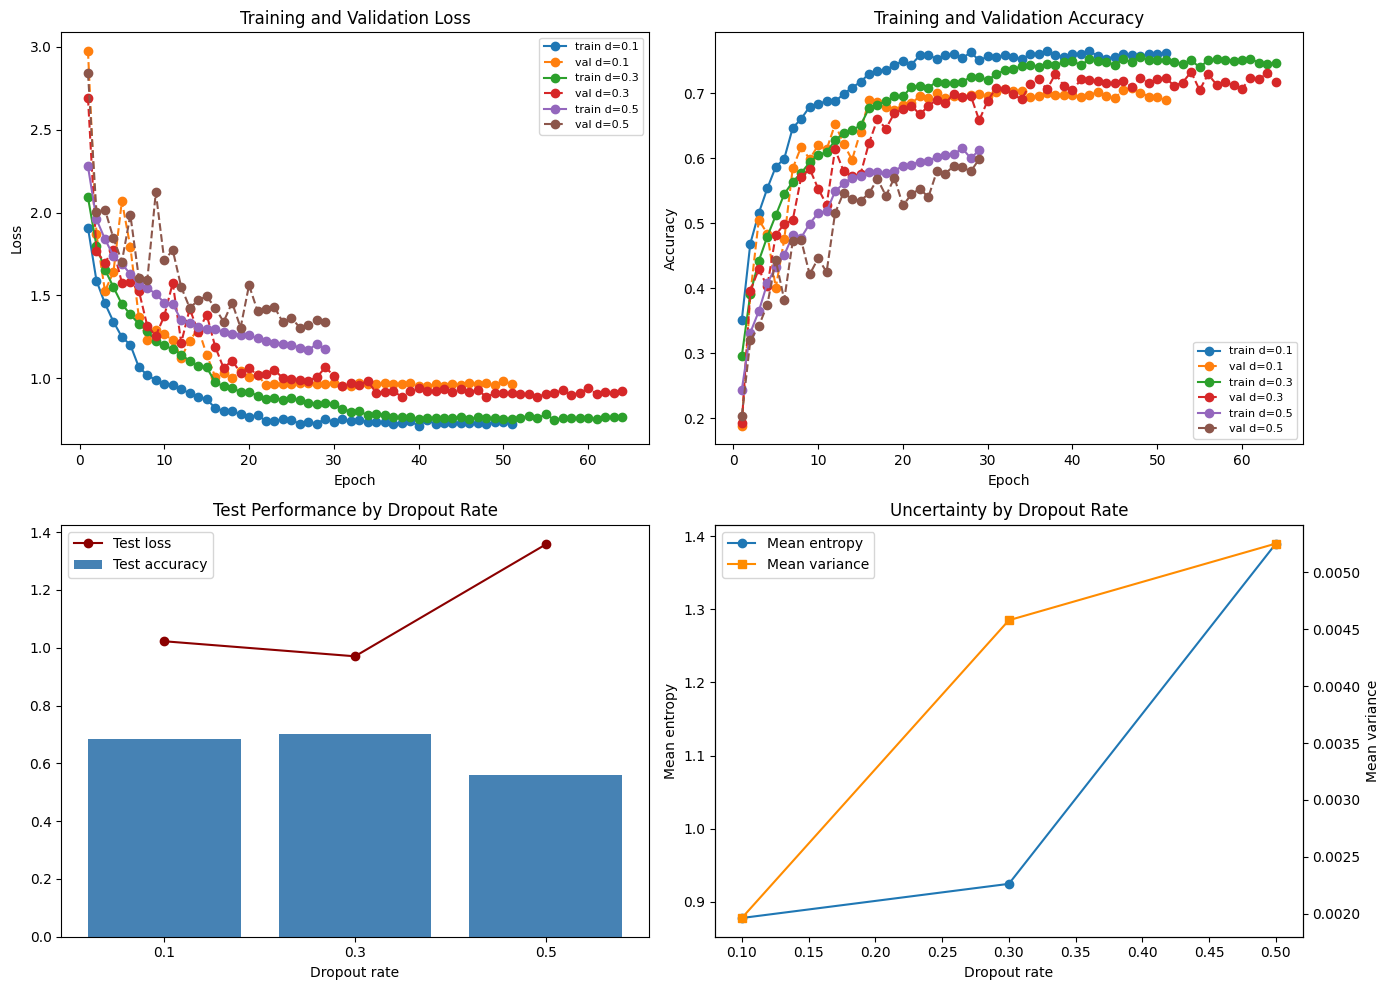

In [21]:
if "experiment_results" not in globals() or not experiment_results:
    experiment_results, best_result, experiment_histories = load_experiment_state_from_artifact()
    print("Loaded experiment state from W&B artifacts.")

best_by_test_accuracy = max(experiment_results, key=lambda result: result["test_accuracy"])
lowest_uncertainty = min(experiment_results, key=lambda result: result["mean_entropy"])

print(f"Best dropout rate by validation loss: {best_result['dropout_rate']}")
print(f"Best dropout rate by test accuracy: {best_by_test_accuracy['dropout_rate']}")
print(f"Lowest mean predictive entropy: {lowest_uncertainty['dropout_rate']}")

dropout_rates = [result["dropout_rate"] for result in experiment_results]
test_accuracies = [result["test_accuracy"] for result in experiment_results]
test_losses = [result["test_loss"] for result in experiment_results]
mean_entropies = [result["mean_entropy"] for result in experiment_results]
mean_variances = [result["mean_variance"] for result in experiment_results]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for dropout_rate, history in experiment_histories.items():
    epochs = range(1, len(history["loss"]) + 1)
    axes[0, 0].plot(epochs, history["loss"], marker="o", label=f"train d={dropout_rate}")
    axes[0, 0].plot(epochs, history["val_loss"], linestyle="--", marker="o", label=f"val d={dropout_rate}")
    axes[0, 1].plot(epochs, history["accuracy"], marker="o", label=f"train d={dropout_rate}")
    axes[0, 1].plot(epochs, history["val_accuracy"], linestyle="--", marker="o", label=f"val d={dropout_rate}")

axes[0, 0].set_title("Training and Validation Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend(fontsize=8)

axes[0, 1].set_title("Training and Validation Accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].legend(fontsize=8)

axes[1, 0].bar([str(rate) for rate in dropout_rates], test_accuracies, color="steelblue", label="Test accuracy")
axes[1, 0].plot([str(rate) for rate in dropout_rates], test_losses, color="darkred", marker="o", label="Test loss")
axes[1, 0].set_title("Test Performance by Dropout Rate")
axes[1, 0].set_xlabel("Dropout rate")
axes[1, 0].legend()

axes[1, 1].plot(dropout_rates, mean_entropies, marker="o", label="Mean entropy")
axes[1, 1].set_title("Uncertainty by Dropout Rate")
axes[1, 1].set_xlabel("Dropout rate")
axes[1, 1].set_ylabel("Mean entropy")

ax_variance = axes[1, 1].twinx()
ax_variance.plot(dropout_rates, mean_variances, color="darkorange", marker="s", label="Mean variance")
ax_variance.set_ylabel("Mean variance")

lines_left, labels_left = axes[1, 1].get_legend_handles_labels()
lines_right, labels_right = ax_variance.get_legend_handles_labels()
axes[1, 1].legend(lines_left + lines_right, labels_left + labels_right, loc="upper left")

plt.tight_layout()

if wandb.run is None:
    wandb_summary_run = wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name="notebook-04-summary",
        group=WANDB_GROUP,
        job_type="analysis",
        reinit="finish_previous",
    )

wandb.log({"dropout_comparison": wandb.Image(fig)})
wandb.finish()

plt.show()
